### Quantify percentage of body area moving from the video
[1] https://gist.github.com/pknowledge/623515e8ab35f1771ca2186630a13d14

[2] https://www.learnopencv.com/how-to-select-a-bounding-box-roi-in-opencv-cpp-python/

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from __future__ import division
import os

In [2]:
fps=30 #frame rate

def crop(frame,r):
    frame=frame[r[1]:r[1]+r[3],r[0]:r[0]+r[2]]
    return frame

In [3]:
def get_ROI(path_in):
    
    cap = cv2.VideoCapture(path_in)
    _,im=cap.read() 
    r = cv2.selectROI(im)
    imCrop = im[int(r[1]):int(r[1]+r[3]), int(r[0]):int(r[0]+r[2])]
    cv2.imshow("Image", imCrop)
    cv2.waitKey(0)
    
    return r

In [4]:
def main(path_in,au,r):
    cap = cv2.VideoCapture(path_in)
    _,f1=cap.read() ##old frame
    f1=crop(f1,r)
    timer,flag,onset=0,0,-1
    mov=[]
    fourcc = cv2.VideoWriter_fourcc('X','V','I','D')
    out_vid=cv2.VideoWriter(path2_dataset+'/videos_quantifymov/'+'detect/'+au+'-detect.mp4', fourcc, 30, (len(f1[0]),len(f1)))

    while(cap.isOpened()):

        ret,f2= cap.read() #new frame
        if ret:
            f2=crop(f2,r) #crop frame
            diff = cv2.absdiff(f1, f2) 
            gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
            _, thresh = cv2.threshold(gray,20, 255, cv2.THRESH_BINARY)
            cnts,_ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

            if len(cnts):
                percentage=[]
                for cnt in cnts:
                    (x, y, w, h) = cv2.boundingRect(cnt)
                    percentage.append((w*h)/(r[2]*r[3]))

                mov.append(sum(percentage))
                if len(percentage):
                    idx=percentage.index(max(percentage))
                    (x, y, w, h) = cv2.boundingRect(cnts[idx])
                    cv2.rectangle(f1, (x, y), (x+w, y+h), (0, 255, 0), 2)
                else:
                    mov.append(0)
            else:
                mov.append(0)

            cv2.imshow("processing", f1)
            out_vid.write(f1)
            f1=f2  
            timer+=1/fps


        elif not ret:
            break


        if cv2.waitKey(10) & 0xFF == ord('q'):
                break

    cv2.destroyAllWindows()
    cap.release()
    out_vid.release()
    
    return mov


In [5]:
def str2time(v):
    
    return int(v.split('-')[0])*60+int(v.split('-')[1])

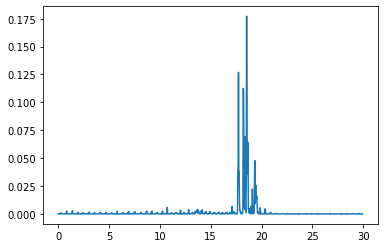

In [6]:
#Add path to dataset
path2_dataset='D:/dataset'
#video name, see 'dataset/videos_quantifymov/'
au='9-29' 

#Choose region of interest (ROI;areas occupied by the animal in the frame)
path_in=os.path.join(path2_dataset,'videos_quantifymov',au+'.avi') 
r=get_ROI(path_in)
path_ROI=os.path.join(path2_dataset,'videos_quantifymov','ROI',au+'.txt')
np.savetxt(path_ROI,r,fmt="%d")

#Detect percentage of body area moving
mov=main(path_in,au,r)

##Save results
path_mov=os.path.join(path2_dataset,'videos_quantifymov','detect',au+'.txt') 
np.savetxt(path_mov,np.array(mov),fmt='%1.3f')

x=np.arange(0,len(mov)/fps,1/fps)
if len(x)==len(mov):
    plt.plot(x,mov)
else:
    plt.plot(x[:len(mov)],mov)
